In [3]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt

In [53]:
# define hamiltonians

def transmon_H(EJ, EC, ng=0.0, tmon_trunc=13):
    dim = 2*tmon_trunc + 1
    ns = np.arange(-tmon_trunc, tmon_trunc+1, dtype=float)
    H_C = qt.qdiags(4*EC*(ns - ng)**2, 0)
    H_J = qt.qdiags(np.ones(dim-1), 1) + qt.qdiags(np.ones(dim-1), -1)
    return H_C - 0.5 * EJ * H_J, ns

def cavity_H(wr, cav_trunc=100):
    a = qt.destroy(cav_trunc)
    return wr * a.dag() * a

def dressed_H(EJ, EC, wr, g, ng=0.0, tmon_trunc=13, cav_trunc=100):
    H_tmon, ns = transmon_H(EJ, EC, ng=ng, tmon_trunc=tmon_trunc)
    n_op = qt.qdiags(ns - ng, 0) 

    a = qt.destroy(cav_trunc)
    I_t = qt.qeye(2*tmon_trunc + 1)
    I_c = qt.qeye(cav_trunc)

    H_tot = (qt.tensor(H_tmon, I_c) 
             + wr * qt.tensor(I_t, a.dag() * a) 
             - 1j * g * qt.tensor(n_op, a - a.dag()) )
    
    return H_tot

In [104]:
# define parameters

EC = 0.22 # GHz
EJ = 110 * EC
ng = 0.0
tmon_trunc = 15

wr = 7.5 # GHz
cav_trunc = 200

g = 0.120 # GHz

In [105]:
# first, build  bare hamiltonian and its eigenstates

H_tmon, _= transmon_H(EJ, EC, ng=ng, tmon_trunc=tmon_trunc)
tmon_evals, tmon_evecs = H_tmon.eigenstates()
tmon_evals -= tmon_evals[0]
n_bound_states = 2*tmon_trunc + 1
print(f"Transmon frequency = {tmon_evals[1]}, anharmonicity = {(tmon_evals[1] - tmon_evals[0]) - (tmon_evals[2] - tmon_evals[1])}")

H_cav = cavity_H(wr, cav_trunc=cav_trunc)
cav_evals, cav_evecs = H_cav.eigenstates()

bare_eigenstates = []
for i in range(n_bound_states):
    for n in range(cav_trunc):
        bare_eigenstates.append(qt.tensor(tmon_evecs[i], cav_evecs[n]))

# then, get hamiltonian of coupled system

H_dressed = dressed_H(EJ, EC, wr, g, ng=ng, tmon_trunc=tmon_trunc, cav_trunc=cav_trunc)
dressed_evals, dressed_evecs = H_dressed.eigenstates()

Transmon frequency = 6.2980878945353425, anharmonicity = 0.2398355678193056


In [106]:
# do branch analysis

relabeled_dressed_states = []
assigned = np.zeros(n_bound_states * cav_trunc)

create_op = qt.tensor(qt.qeye(2*tmon_trunc+1), qt.create(cav_trunc))
destroy_op = qt.tensor(qt.qeye(2*tmon_trunc+1), qt.destroy(cav_trunc))

for i in range(n_bound_states):
    for n in range(cav_trunc):
        if n == 0:
            compare_state = bare_eigenstates[i * cav_trunc]
        else:
            compare_state = create_op * relabeled_dressed_states[i * cav_trunc + (n - 1)]
            compare_state = compare_state.unit()

        cur_overlap = -1 
        cur_state = -1
        for k in range(n_bound_states * cav_trunc):
            if assigned[k] == 0:
                overlap = np.abs(dressed_evecs[k].overlap(compare_state)) ** 2
                if overlap == -1 or overlap > cur_overlap:
                    cur_overlap = overlap
                    cur_state = k

        assigned[cur_state] = 1
        relabeled_dressed_states.append(dressed_evecs[cur_state])

In [107]:
# compute Nt and Nr

Nt = np.zeros(n_bound_states * cav_trunc)
Nr = np.zeros(n_bound_states * cav_trunc)

for i in range(n_bound_states):
    for n in range(cav_trunc):
        dressed_idx = i * cav_trunc + n
        dressed_state = relabeled_dressed_states[dressed_idx] 
        Nr[dressed_idx] = np.real(dressed_state.overlap(create_op * destroy_op * dressed_state))

        for j in range(n_bound_states):
            for m in range(cav_trunc):
                bare_idx = j * cav_trunc + m
                Nt[dressed_idx] += j * (np.abs(relabeled_dressed_states[dressed_idx].overlap(bare_eigenstates[bare_idx])) ** 2)

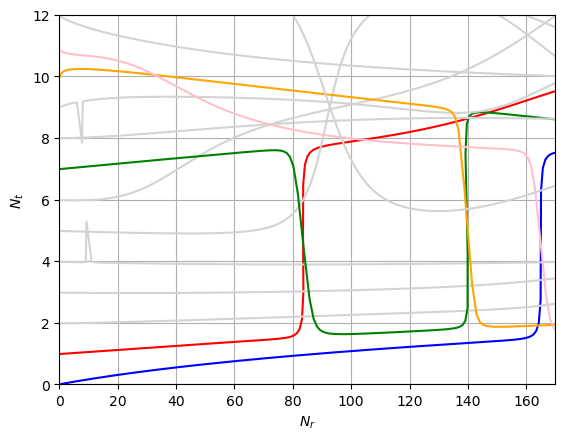

In [112]:
colors = ["lightgray"] * (2*tmon_trunc + 1)
colors[0] = "blue"
colors[1] = "red"
colors[7] = "green"
colors[10] = "orange"
colors[11] = "pink"

for i in range(n_bound_states):
    start = i * cav_trunc
    end = (i+1) * cav_trunc
    # plt.plot(Nr[start:end], Nt[start:end], marker=".", linestyle="", label=f"${i}_t$")
    plt.plot(Nr[start:end], Nt[start:end], color=colors[i], label=f"${i}_t$")
plt.xlim(0, 170)
plt.ylim(0, 12)
plt.xlabel("$N_r$")
plt.ylabel("$N_t$")
# plt.legend()
plt.grid()
plt.show()